In [1]:
from __future__ import print_function, division
import kagglehub
import shutil
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import models

In [2]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

# Моя часть

In [3]:
basic_model = models.resnet18(weights='IMAGENET1K_V1')

In [5]:
def create_model_parameters(variant_name, base_model):
  for param in base_model.parameters():
        param.requires_grad = False

  in_feat = base_model.fc.in_features

  criterion = nn.CrossEntropyLoss()

  if variant_name == 'A': # Linear -> ReLU -> BN -> Dropout -> Linear
      base_model.fc = nn.Sequential(nn.Linear(in_feat, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.5), nn.Linear(256, 9))
  elif variant_name == 'B': # Linear -> BN -> ReLU -> Dropout -> Linear
      base_model.fc = nn.Sequential(nn.Linear(in_feat, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 9))
  elif variant_name == 'C': # Без Dropout (только BN)
      base_model.fc = nn.Sequential(nn.Linear(in_feat, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Linear(256, 9))
  elif variant_name == 'D': # LayerNorm вместо BN
      base_model.fc = nn.Sequential(nn.Linear(in_feat, 256), nn.LayerNorm(256), nn.ReLU(), nn.Linear(256, 9))

  base_model = base_model.to(device)

  optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, base_model.parameters()),
        lr=0.001,
        momentum=0.9
      )
  scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

  return base_model.to(device), criterion, optimizer, scheduler

In [6]:
from copy import deepcopy

In [7]:
def start_all_experiments(basic_model, var):
    model, criterion, optimizer, scheduler = create_model_parameters(var, deepcopy(basic_model))
    model_done, metrics = train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, 25)
    return model_done, metrics

In [8]:
models = []
for v in ['A', 'B', 'C', 'D']:
    mod, metr = start_all_experiments(basic_model, v)
    models.append((mod, metr))

val Loss: 1.0565 | Acc: 0.6254 | Weighted Acc: 0.5752 | F1-macro: 0.6167 | Top-1 Acc: 0.6254 | Top-3 Acc: 0.8998
Epoch Time: 19.0747s

Training complete in 7m 58s
Best val Weighted Acc: 0.592755 | Best F1-score: 0.6295 | Best Top-1 Acc: 0.6336 | Best Top-3 Acc: 0.9104


# BatchNorm after ReLU

In [9]:
mod1, metr1 = models[0]

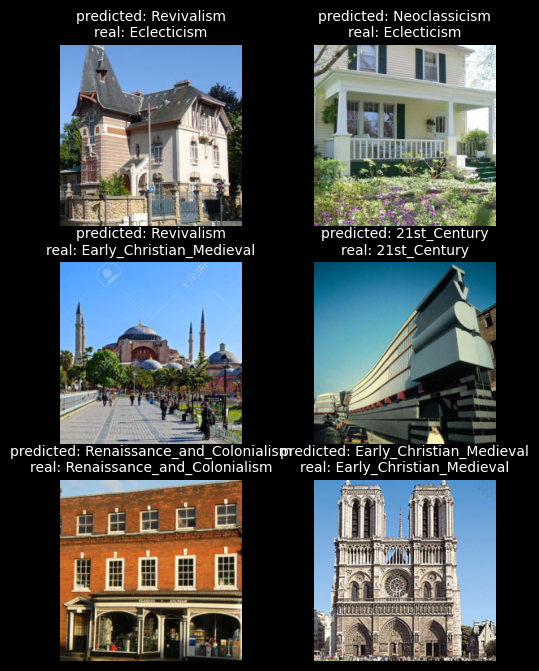

In [10]:
visualize_model(mod1, num_images=6, class_names=class_names, vis_loader=vis_loader)

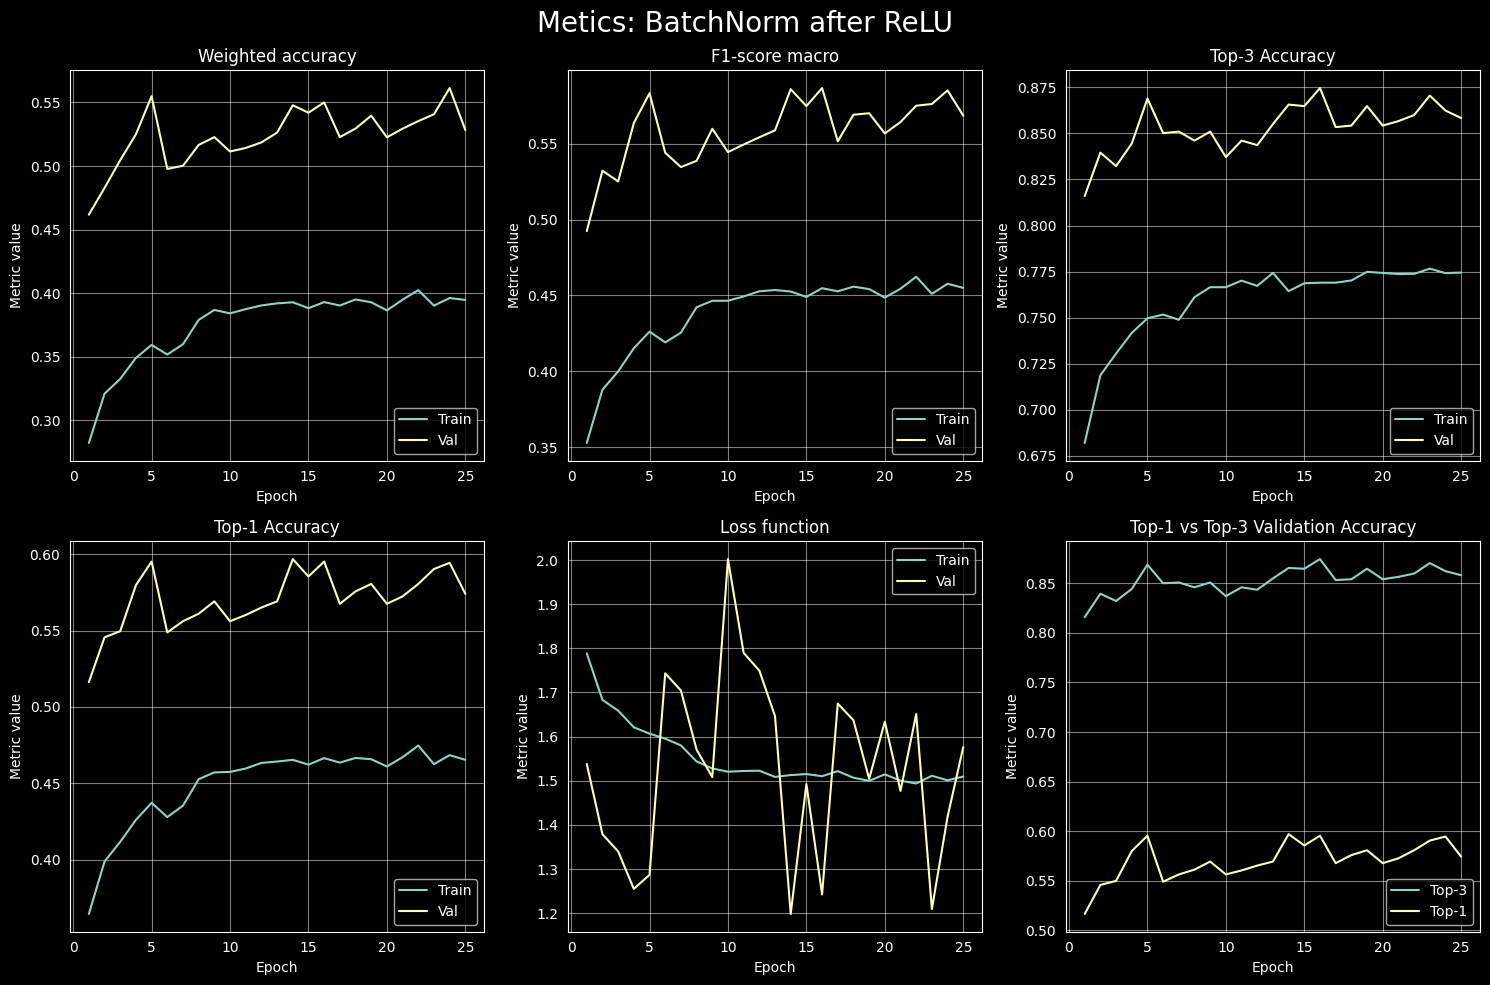

In [11]:
visualize_metrics(metr1, "Metics: BatchNorm after ReLU", 25)

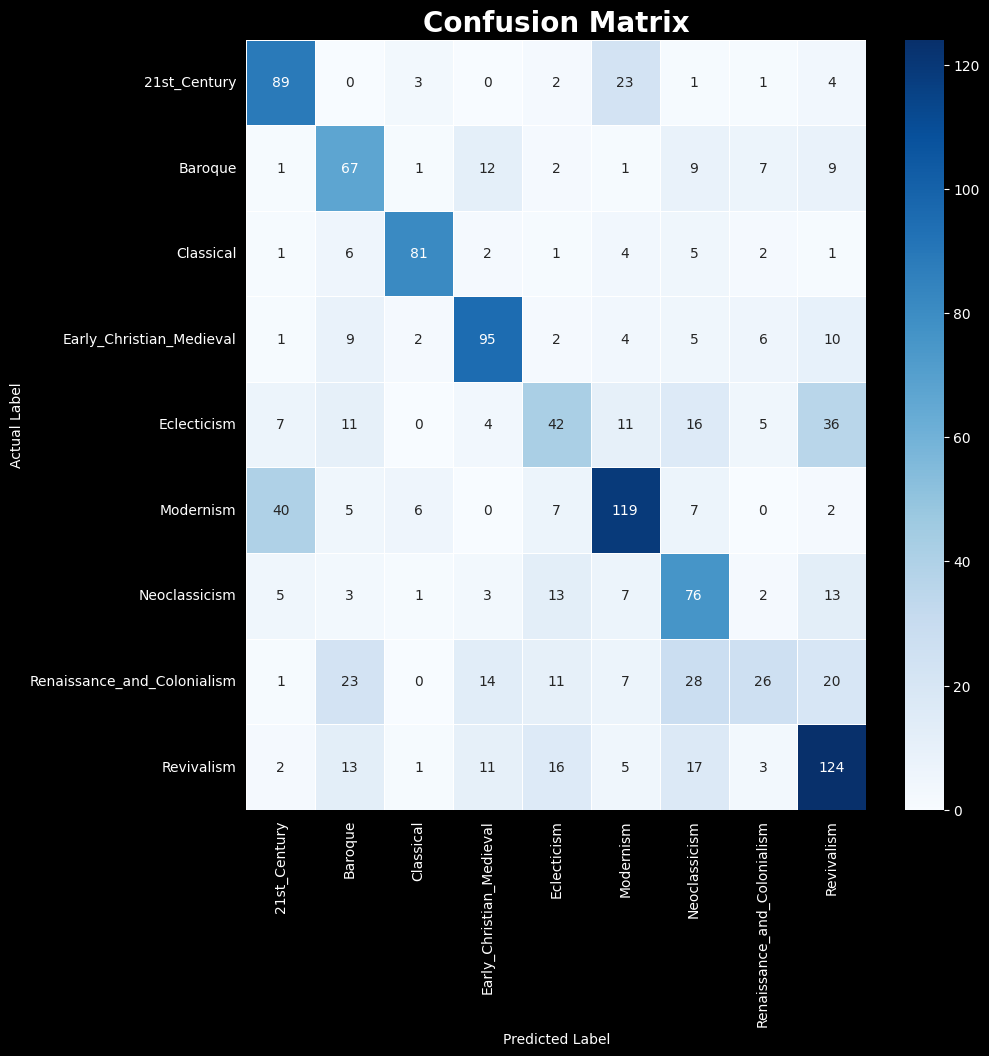

In [12]:
visualize_cm(mod1, class_names, test_set)

# BatchNorm before ReLU

In [13]:
mod2, metr2 = models[1]

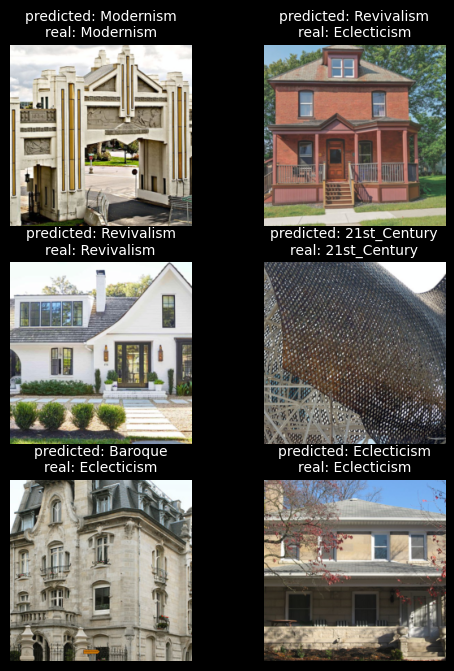

In [14]:
visualize_model(mod2, num_images=6, class_names=class_names, vis_loader=vis_loader)

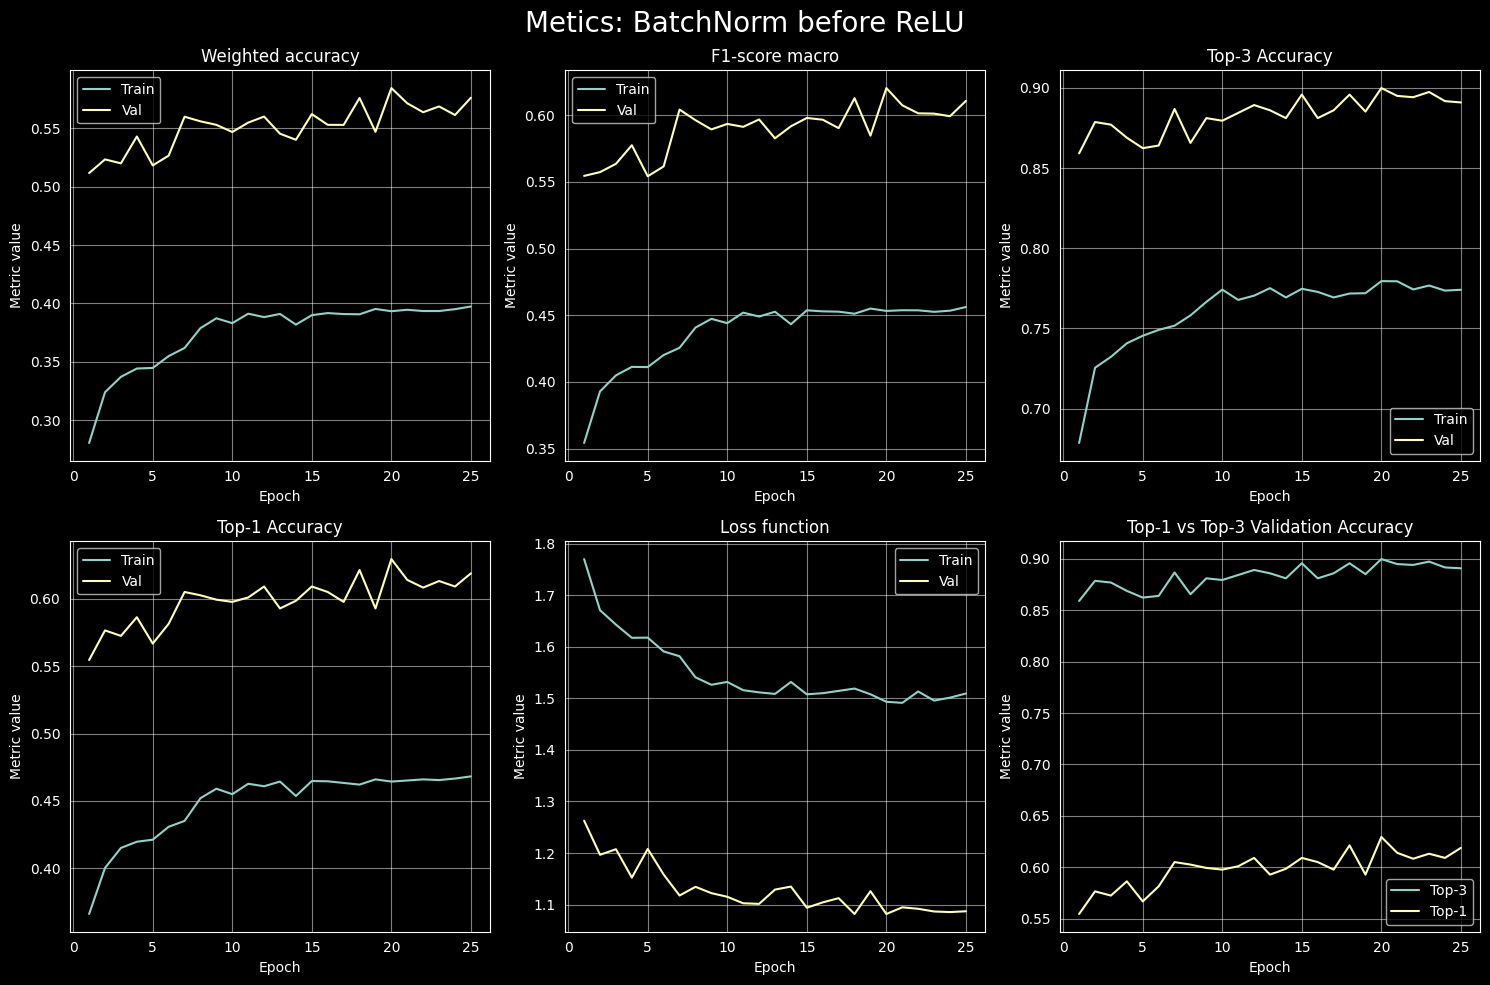

In [15]:
visualize_metrics(metr2, "Metics: BatchNorm before ReLU", 25)

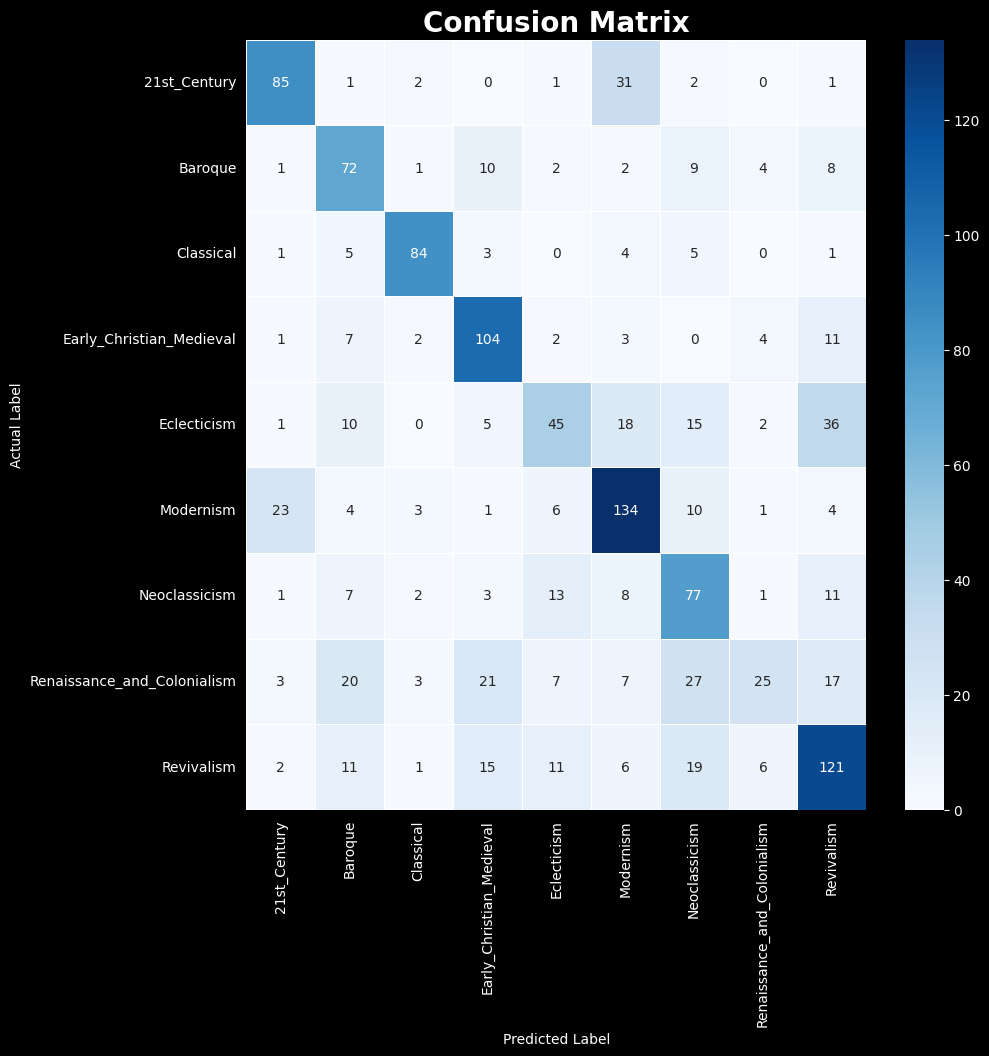

In [16]:
visualize_cm(mod2, class_names, test_set)

# BatchNorm + no Dropout

In [17]:
mod3, metr3 = models[2]

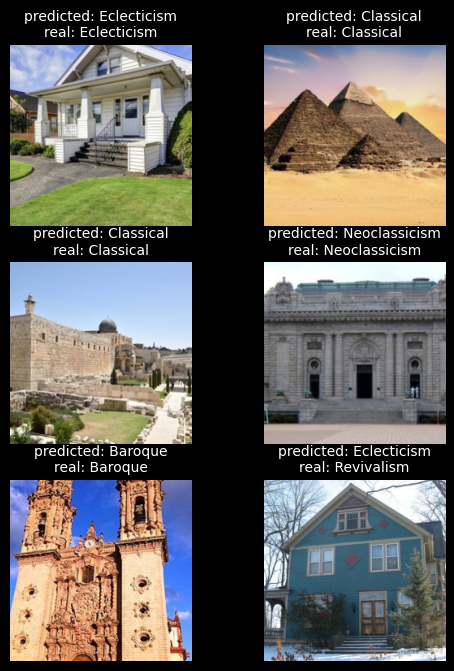

In [18]:
visualize_model(mod3, num_images=6, class_names=class_names, vis_loader=vis_loader)

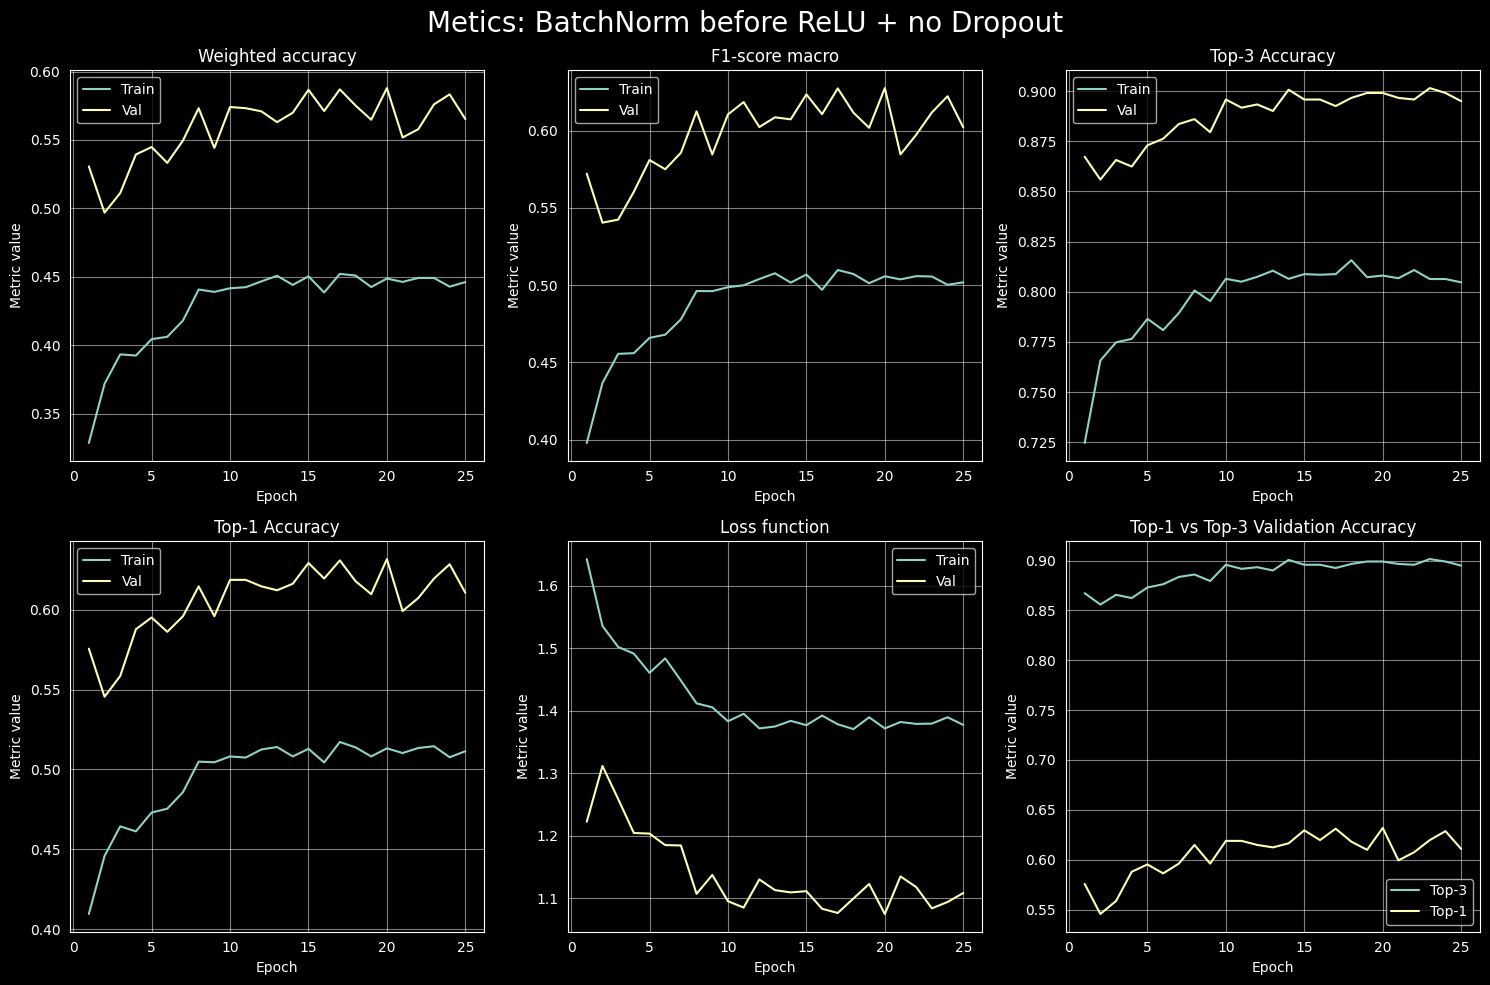

In [19]:
visualize_metrics(metr3, "Metics: BatchNorm before ReLU + no Dropout", 25)

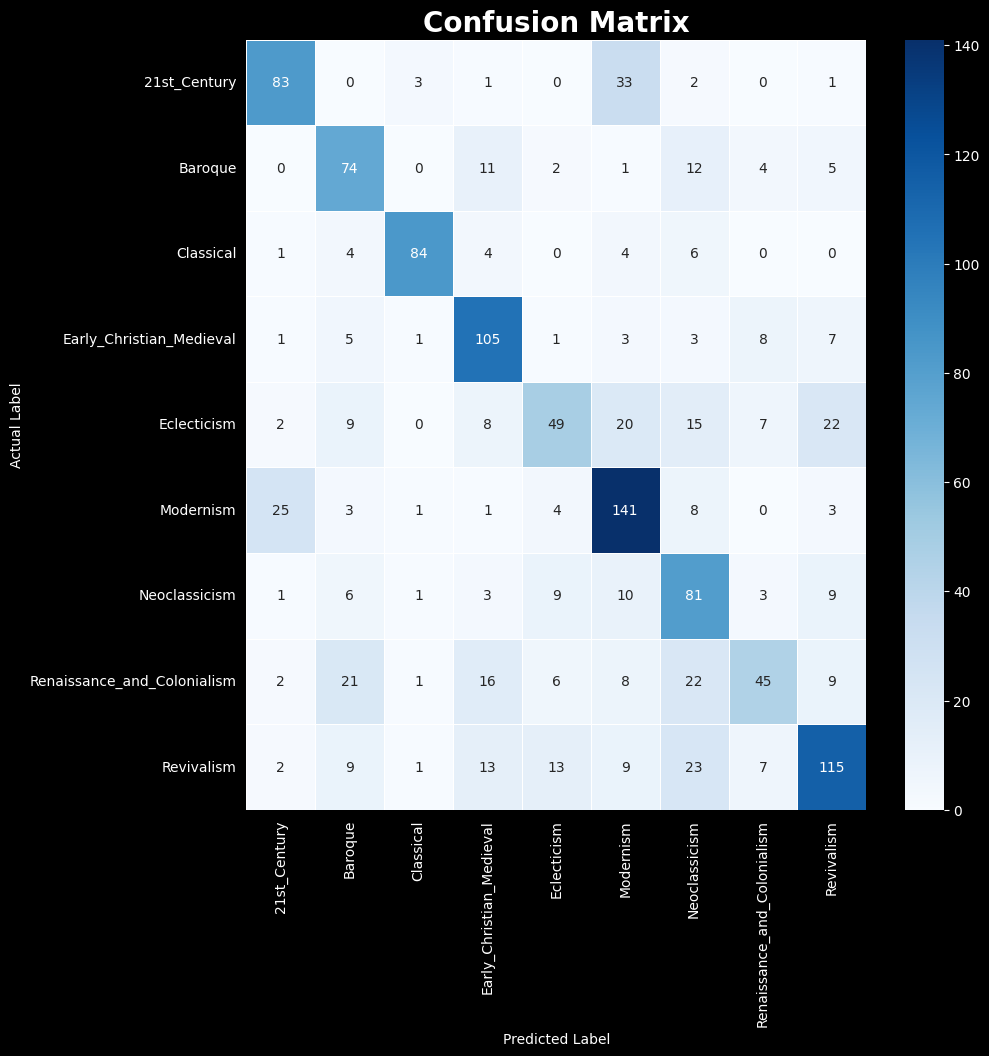

In [20]:
visualize_cm(mod3, class_names, test_set)

# LayerNorm

In [21]:
mod4, metr4 = models[3]

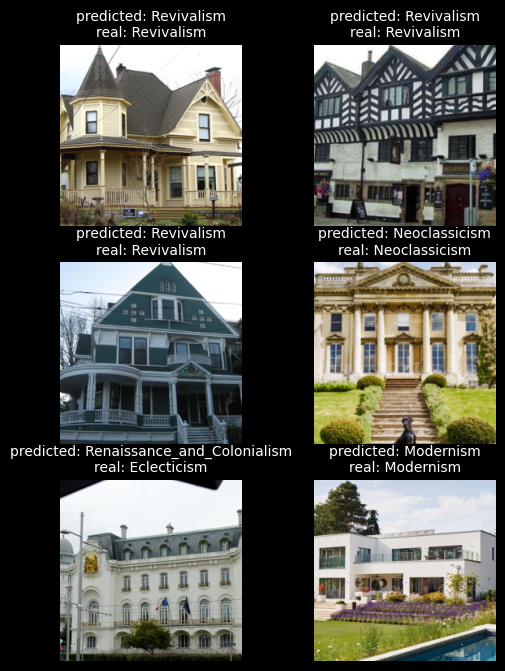

In [22]:
visualize_model(mod4, num_images=6, class_names=class_names, vis_loader=vis_loader)

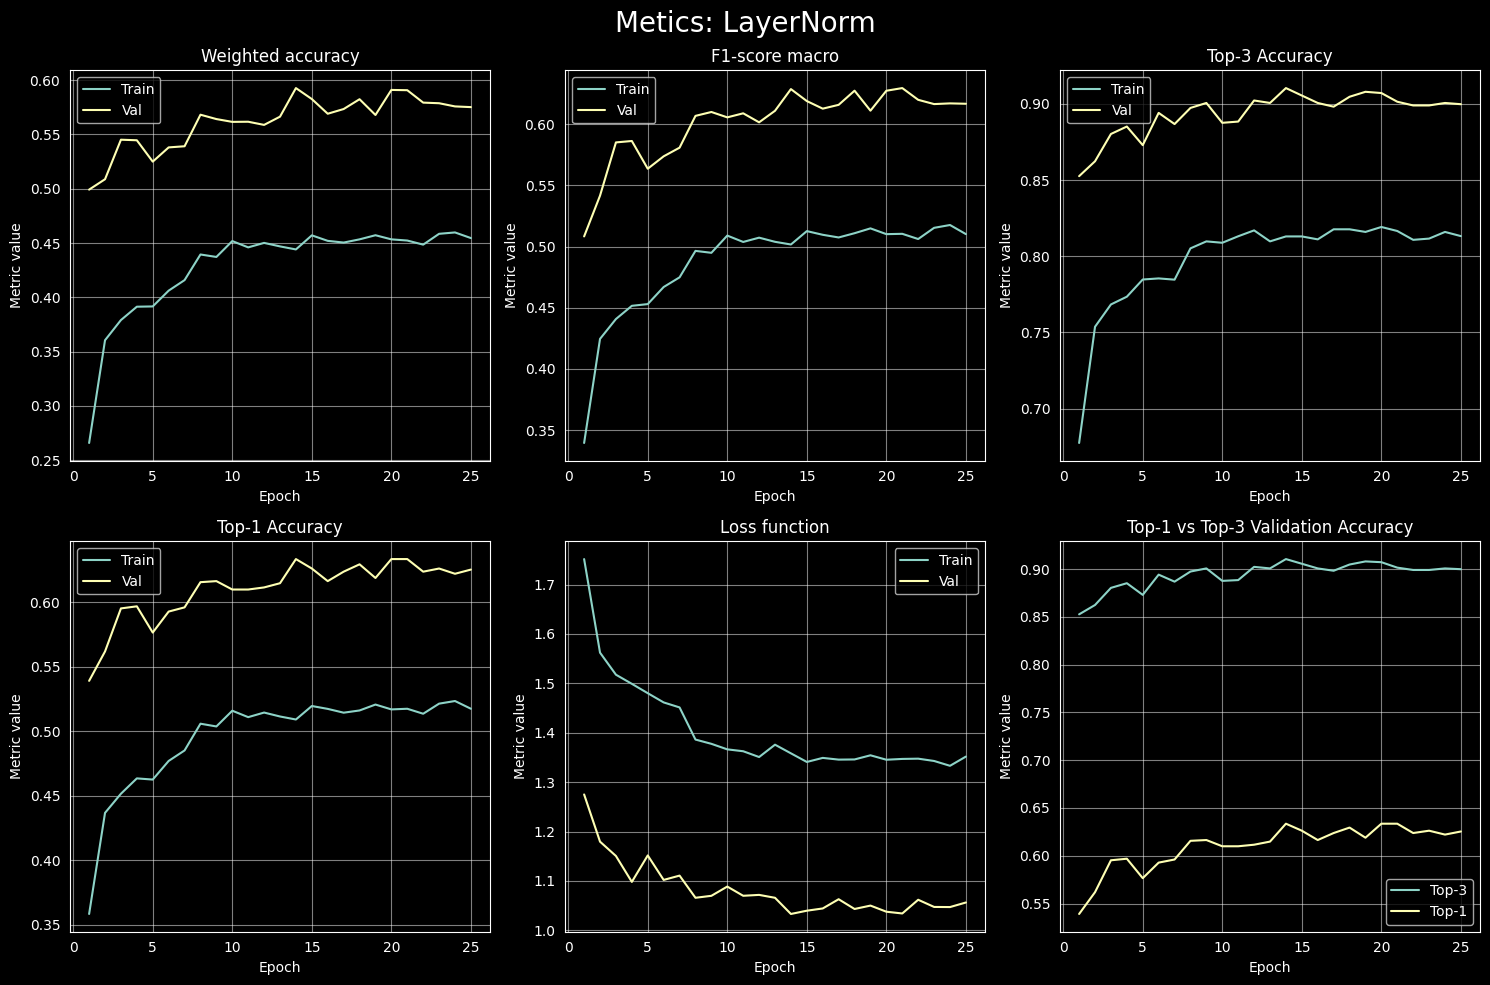

In [23]:
visualize_metrics(metr4, "Metics: LayerNorm", 25)

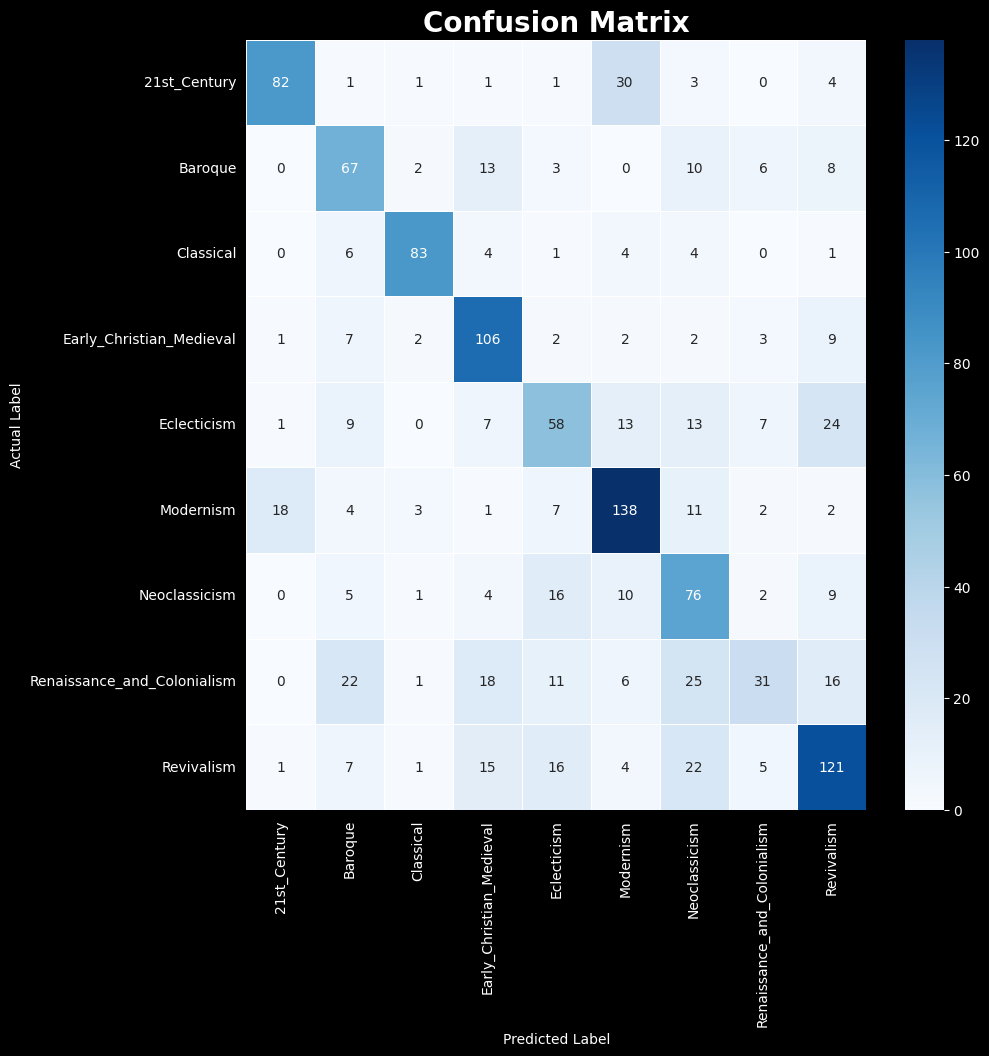

In [24]:
visualize_cm(mod4, class_names, test_set)

In [25]:
torch.save(mod1, "BN_after_ReLU.pt")
torch.save(mod2, "BN_before_ReLU.pt")
torch.save(mod3, "BN_before_ReLU_no_Dropout.pt")
torch.save(mod4, "LayerNorm.pt")